In [376]:
import os
import matplotlib.pyplot as plt
from matplotlib import colormaps
from src.models.NSI import NSI
from src.models.channel import *
from src.models.continuous_graph_model import *
from src.models.continuous_models import NoisyGillespie
from tqdm.notebook import tqdm
import pickle
import matplotlib.patches as mpatches
import matplotlib.colors as mcolors
from scipy import stats
from scipy.interpolate import interp1d
from collections import defaultdict
import numpy as np
import networkx as nx
import matplotlib
from itertools import product
import itertools
import seaborn as sns

In [2]:
TEST = nx.barabasi_albert_graph(m=2, n=1000)
TEST_2 = nx.erdos_renyi_graph(n=1000, p=0.1)
TEST_3 = nx.complete_graph(n=1000)

In [3]:
sorted(dict(TEST.degree).items(), key=lambda x: x[1])[-1][0]

2

In [6]:
beta = 0.01
e = 0.01
initial_state = {0: 0}
Q = np.array([[1-e, e], [e, 1-e]])

initial_state_max = {sorted(dict(TEST.degree).items(), key=lambda x: x[1])[-1][0]: 0}

In [7]:
# Create the Gillespie simulation object
test_gillespie = NetworkGillespie(G=TEST, initial_infected=initial_state, beta=beta, channel=Q)
test_gillespie_2 = NetworkGillespie(G=TEST_2, initial_infected=initial_state, beta=beta, channel=Q)
test_gillespie_3 = NetworkGillespie(G=TEST_3, initial_infected=initial_state, beta=beta, channel=Q)
test_gillespie_4 = NetworkGillespie(G=TEST, initial_infected=initial_state_max, beta=beta, channel=Q)

In [8]:
test_sim = test_gillespie.simulate(max_time=1000)
test_sim_2 = test_gillespie_2.simulate(max_time=1000)
test_sim_3 = test_gillespie_3.simulate(max_time=1000)
test_sim_4 = test_gillespie_4.simulate(max_time=1000)

(0.0, 100.0)

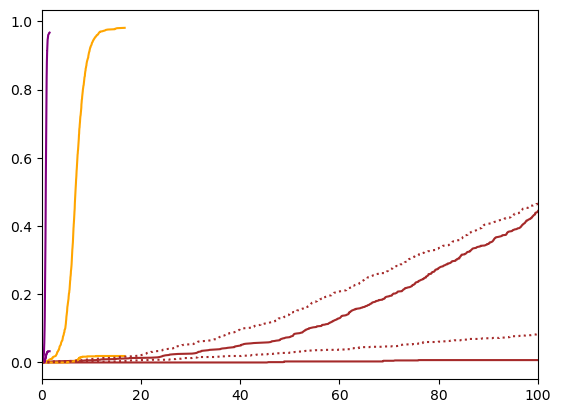

In [9]:
plt.plot(test_sim[0], test_sim[1], color='brown')
plt.plot(test_sim_2[0], test_sim_2[1], color='orange')
plt.plot(test_sim_3[0], test_sim_3[1], color='purple')
plt.plot(test_sim_4[0], test_sim_4[1], color='brown', linestyle='dotted')
plt.xlim(0,100)

In [10]:
test_sim[1][-1], test_sim_2[1][-1], test_sim_3[1][-1], test_sim_4[1][-1]

(array([0.985, 0.015]),
 array([0.981, 0.019]),
 array([0.967, 0.033]),
 array([0.829, 0.171]))

## Mutual Info

First, assume that the same "observers" directly observe every time.
Then, we can move on and consider a case where the message is randomly seeded.

In [5]:
%%time
test_s1 = nx.geometric_soft_configuration_graph(beta=1.2, n=10000, gamma=2.5, mean_degree=10)

CPU times: user 24.9 s, sys: 0 ns, total: 24.9 s
Wall time: 24.9 s


In [270]:
np.logspace(-1, 2, 11)

array([  0.1       ,   0.19952623,   0.39810717,   0.79432823,
         1.58489319,   3.16227766,   6.30957344,  12.58925412,
        25.11886432,  50.11872336, 100.        ])

In [306]:
N = 1000
k_mean = 4

gammas = np.linspace(2, 3, 11)
#inv_temps = np.linspace(0.5, 5.5, 11)[:-1]
inv_temps = np.logspace(-1, 2, 11)

ensemble = {}
for gamma, b in tqdm(itertools.product(gammas, inv_temps), total=len(gammas) * len(inv_temps)):
    g = nx.geometric_soft_configuration_graph(n=N, gamma=gamma, beta=b, mean_degree=10)
    ensemble[(round(gamma, 3), round(b, 3))] = g
    
#with open("/data_users1/sagar/modeling-info-spread/s1_ensemble_cpu.pkl", "wb") as f:
#    pickle.dump(ensemble, f)

  0%|          | 0/100 [00:00<?, ?it/s]

In [388]:
ensemble.keys()

dict_keys([(2.1, 0.1), (2.1, 0.2), (2.1, 0.398), (2.1, 0.794), (2.1, 1.585), (2.1, 3.162), (2.1, 6.31), (2.1, 12.589), (2.1, 25.119), (2.1, 50.119), (2.2, 0.1), (2.2, 0.2), (2.2, 0.398), (2.2, 0.794), (2.2, 1.585), (2.2, 3.162), (2.2, 6.31), (2.2, 12.589), (2.2, 25.119), (2.2, 50.119), (2.3, 0.1), (2.3, 0.2), (2.3, 0.398), (2.3, 0.794), (2.3, 1.585), (2.3, 3.162), (2.3, 6.31), (2.3, 12.589), (2.3, 25.119), (2.3, 50.119), (2.4, 0.1), (2.4, 0.2), (2.4, 0.398), (2.4, 0.794), (2.4, 1.585), (2.4, 3.162), (2.4, 6.31), (2.4, 12.589), (2.4, 25.119), (2.4, 50.119), (2.5, 0.1), (2.5, 0.2), (2.5, 0.398), (2.5, 0.794), (2.5, 1.585), (2.5, 3.162), (2.5, 6.31), (2.5, 12.589), (2.5, 25.119), (2.5, 50.119), (2.6, 0.1), (2.6, 0.2), (2.6, 0.398), (2.6, 0.794), (2.6, 1.585), (2.6, 3.162), (2.6, 6.31), (2.6, 12.589), (2.6, 25.119), (2.6, 50.119), (2.7, 0.1), (2.7, 0.2), (2.7, 0.398), (2.7, 0.794), (2.7, 1.585), (2.7, 3.162), (2.7, 6.31), (2.7, 12.589), (2.7, 25.119), (2.7, 50.119), (2.8, 0.1), (2.8, 0.2),

In [307]:
[len(g.edges) for g in ensemble.values()]

[3464,
 3324,
 3146,
 2973,
 3932,
 3710,
 4065,
 3707,
 5309,
 4399,
 4496,
 3377,
 5695,
 2582,
 4552,
 4533,
 4668,
 4721,
 4127,
 6042,
 4441,
 4043,
 4171,
 3629,
 4298,
 4346,
 4644,
 5425,
 4669,
 6464,
 4107,
 3789,
 4885,
 2822,
 4075,
 4402,
 5221,
 3677,
 4202,
 4400,
 4958,
 4618,
 3716,
 3528,
 4323,
 4514,
 5012,
 4479,
 5355,
 5320,
 4832,
 4831,
 4717,
 3589,
 4457,
 4551,
 4587,
 5484,
 4741,
 4339,
 4805,
 4709,
 4428,
 3918,
 4500,
 5277,
 5539,
 5300,
 5347,
 4816,
 4644,
 4884,
 4392,
 3573,
 4354,
 4979,
 5275,
 4887,
 4879,
 5063,
 4828,
 4462,
 4756,
 3783,
 5065,
 4656,
 5091,
 4723,
 5118,
 4964,
 4914,
 4447,
 4607,
 3665,
 4372,
 4722,
 5155,
 5114,
 5480,
 5372]

In [308]:
nx.is_connected(list(ensemble.values())[-8])

False

In [309]:
testcc = sorted(nx.connected_components(list(ensemble.values())[-8]), key=len, reverse=True)
test0 = list(ensemble.values())[-8].subgraph(testcc[0])
len(test0.edges)

4607

In [310]:
ensemble_cc = {}

for params, g in tqdm(ensemble.items(), total=len(ensemble.keys())):
    cc = sorted(nx.connected_components(g), key=len, reverse=True)
    largest_cc = g.subgraph(cc[0])
    ensemble_cc[params] = nx.convert_node_labels_to_integers(largest_cc)

  0%|          | 0/100 [00:00<?, ?it/s]

In [377]:
beta = 0.05
e = 0.01
Q = np.array([[1-e, e], [e, 1-e]])
num_runs = 10

In [378]:
sims = defaultdict(list)
initial_seed = {np.random.choice(int(N/2)): 0}

for params, g in tqdm(ensemble_cc.items(), total=len(ensemble_cc.keys())):
    obj = NetworkGillespie(G=g, initial_infected=initial_seed, beta=beta, channel=Q)
    for _ in range(num_runs):
        sims[params].append(obj.simulate(max_time=10000))

  0%|          | 0/100 [00:00<?, ?it/s]

In [313]:
# Because it is binary symmetric, we can just pull the symmetry argument and flip the values for the other
# message to get the MI

In [314]:
np.array([0,1])[::-1]

array([1, 0])

In [315]:
test_val = list(sims.values())[0][1][-1]
test_val = test_val[-1] / np.sum(test_val[-1])
test_val
mutual_info(np.array([test_val, test_val[::-1]]), np.array([.5, .5]))

0.7721961340601863

In [316]:
# this doesn't preseve order...
np.mean(np.array([t[1][-1] for t in list(sims.values())[79]]), axis=0)

array([0.68686869, 0.31313131])

In [318]:
#info_arr = np.array([[mutual_info(np.array([sims.get((round(gamma, 3),round(b, 3)))[1][-1], 
#                                  sims.get((round(gamma, 3),round(b, 3)))[1][-1][::-1]]), 
#                                 np.array([0.5, 0.5]))
#                      for b in inv_temps] 
#                     for gamma in gammas])

info_arr = np.zeros((10,10))
for i,gamma in enumerate(gammas):
    for j,b in enumerate(inv_temps):
        idx_pair = round(gamma, 3),round(b, 3)
        sim_list = sims.get(idx_pair)
        mean_times = np.mean(np.array([t[0] for t in sim_list]), axis=0)
        mean_state = np.mean(np.array([x[1][-1] for x in sim_list]), axis=0)
        info = mutual_info(np.array([mean_state, mean_state[::-1]]), np.array([.5, .5]))
        info_arr[i,j] = info
    

<Axes: >

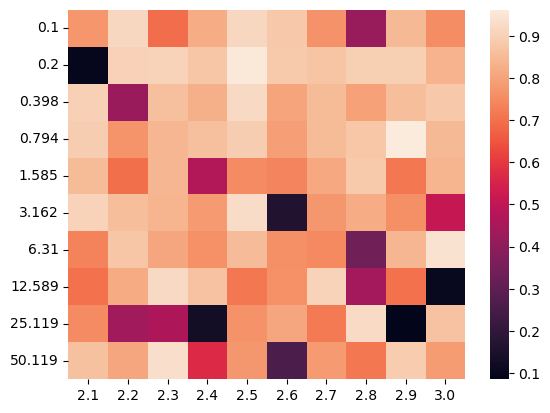

In [319]:
sns.heatmap(info_arr, xticklabels=[round(gamma, 3) for gamma in gammas], 
            yticklabels=[round(b, 3) for b in inv_temps])

In [429]:
beta = 0.05
e = 0.05
Q = np.array([[1-e, e], [e, 1-e]])
num_runs = 100

In [366]:
# Run 5 on the highest degree node and 5 randomly seeded
seed_gamma = 2.5
seed_sims = {round(b, 3): {'targeted': [], 'random': []} for b in inv_temps}

for b in tqdm(inv_temps):
    gamma = round(seed_gamma, 3)
    b = round(b, 3)
    g = ensemble_cc.get((seed_gamma, b))
    
    for _ in range(num_runs):
        random_seed = {np.random.choice(len(g.nodes)): 0}
        rand_obj = NetworkGillespie(G=g, initial_infected=random_seed, beta=beta, channel=Q)
        seed_sims[b]['random'].append(rand_obj.simulate(max_time=10000))
    for _ in range(num_runs):
        random_seed = {sorted(dict(g.degree).items(), key=lambda x: x[1])[-1][0] : 0}
        rand_obj = NetworkGillespie(G=g, initial_infected=random_seed, beta=beta, channel=Q)
        seed_sims[b]['targeted'].append(rand_obj.simulate(max_time=10000))


  0%|          | 0/10 [00:00<?, ?it/s]

In [367]:
np.array([x[1][-1] for x in seed_sims.get(inv_temps[0])['targeted']])

array([[0.94360524, 0.05639476],
       [0.95770393, 0.04229607],
       [0.95568983, 0.04431017],
       [0.98288016, 0.01711984],
       [0.97280967, 0.02719033],
       [0.97482377, 0.02517623],
       [0.97985901, 0.02014099],
       [0.94058409, 0.05941591],
       [0.97784491, 0.02215509],
       [0.98590131, 0.01409869]])

In [368]:
len(seed_sims.get(inv_temps[0])['targeted'][5][1]), seed_sims.get(inv_temps[0])['targeted'][5][0][-1]

(993, 74.78207248511902)

In [369]:
seed_sims.keys()

dict_keys([0.1, 0.2, 0.398, 0.794, 1.585, 3.162, 6.31, 12.589, 25.119, 50.119])

In [370]:
inv_temps

array([ 0.1       ,  0.19952623,  0.39810717,  0.79432823,  1.58489319,
        3.16227766,  6.30957344, 12.58925412, 25.11886432, 50.11872336])

(0.0, 1.0)

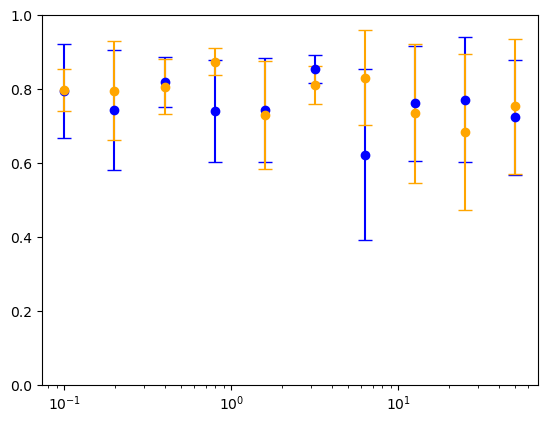

In [373]:
rand_mis = []
targ_mis = []

rand_mi_cis = []
targ_mi_cis = []

for b in inv_temps:
    seed_sim = seed_sims.get(round(b, 3))
    mean_rand_mis = []
    for sim in seed_sim.get('random'):
        final_state = sim[1][-1]
        final_state = final_state/np.sum(final_state)
        mean_rand_mis.append(mutual_info(np.array([final_state, final_state[::-1]]), np.array([.5, .5])))
    
    rand_mi_arr = np.array(mean_rand_mis)
    rand_mean = np.mean(rand_mi_arr) 
    rand_mis.append(rand_mean)
    rand_errs = stats.t.interval(0.95, len(rand_mi_arr)-1, 
                                 loc=rand_mean,
                                 scale=stats.sem(rand_mi_arr))
    rand_mi_cis.append((rand_mean - rand_errs[0], rand_errs[1] - rand_mean))
    
    mean_targ_mis = []
    for sim in seed_sim.get('targeted'):
        final_state = sim[1][-1]
        final_state = final_state/np.sum(final_state)
        mean_targ_mis.append(mutual_info(np.array([final_state, final_state[::-1]]), np.array([.5, .5])))
    
    targ_mi_arr = np.array(mean_targ_mis)
    targ_mean = np.mean(targ_mi_arr)
    targ_mis.append(targ_mean)
    targ_errs = stats.t.interval(0.95, len(targ_mi_arr)-1, 
                                 loc=targ_mean,
                                 scale=stats.sem(targ_mi_arr))
    targ_mi_cis.append((targ_mean - targ_errs[0], targ_errs[1] - targ_mean))
    
    #mean_rand_state = np.mean(np.array([x[1][-1] for x in seed_sim.get('random')]), axis=0)
    #mean_rand_state = mean_rand_state/np.sum(mean_rand_state)
    #
    #mean_targ_state = np.mean(np.array([x[1][-1] for x in seed_sim.get('targeted')]), axis=0)
    #mean_targ_state = mean_targ_state/np.sum(mean_targ_state)
    
    #mi_rand = mutual_info(np.array([mean_rand_state, mean_rand_state[::-1]]), np.array([.5, .5]))
    #mi_targ = mutual_info(np.array([mean_targ_state, mean_targ_state[::-1]]), np.array([.5, .5]))
    #
    #rand_mis.append(mi_rand)
    #targ_mis.append(mi_targ)
    
plt.errorbar(inv_temps, rand_mis, yerr=np.array(rand_mi_cis).T,
         marker='o', linestyle='None', color='blue',
            capsize=5)

plt.errorbar(inv_temps, targ_mis, yerr=np.array(targ_mi_cis).T,
         marker='o', linestyle='None', color='orange',
            capsize=5)

plt.xscale('log')
plt.ylim(0, 1)

In [342]:
rand_mi_cis

[(0.3066484037958312, 0.38263842578252566),
 (0.3152075892544356, 0.3848580674743123),
 (0.31053753864980643, 0.38035338368648847),
 (0.2858485333572512, 0.35559701035479546),
 (0.3075537229593731, 0.3794838325138431),
 (0.29580462682594033, 0.36896574746373345),
 (0.3242346551958659, 0.4011402589364207),
 (0.33862239568703695, 0.408920404003917),
 (0.3453714212944837, 0.4152121164228846),
 (0.29269052055059086, 0.36649441982727915)]

In [430]:
# Run 100 on the highest degree node and 100 randomly seeded
seed_beta_list = [0.1, 1.585, 12.589]
seed_phase_sims = {b: {round(gamma, 3): {'targeted': [], 'random': []} for gamma in gammas} for b in seed_beta_list}

for seed_beta in seed_beta_list:
    for gamma in tqdm(gammas):
        gamma = round(gamma, 3)
        g = ensemble_cc.get((gamma, seed_beta))

        for _ in range(num_runs):
            random_seed = {np.random.choice(len(g.nodes)): 0}
            rand_obj = NetworkGillespie(G=g, initial_infected=random_seed, beta=beta, channel=Q)
            seed_phase_sims[seed_beta][gamma]['random'].append(rand_obj.simulate(max_time=10000))
        for _ in range(num_runs):
            targ_seed = {sorted(dict(g.degree).items(), key=lambda x: x[1])[-1][0] : 0}
            targ_obj = NetworkGillespie(G=g, initial_infected=targ_seed, beta=beta, channel=Q)
            seed_phase_sims[seed_beta][gamma]['targeted'].append(targ_obj.simulate(max_time=10000))


  0%|          | 0/10 [00:00<?, ?it/s]

  0%|          | 0/10 [00:00<?, ?it/s]

  0%|          | 0/10 [00:00<?, ?it/s]

In [431]:
[i.get(2.1)['targeted'][1][-1] for i in seed_phase_sims.values()]

[array([[0.00105374, 0.        ],
        [0.00210748, 0.        ],
        [0.00316122, 0.        ],
        ...,
        [0.80716544, 0.19072708],
        [0.80821918, 0.19072708],
        [0.80927292, 0.19072708]]),
 array([[0.00104058, 0.        ],
        [0.00208117, 0.        ],
        [0.00312175, 0.        ],
        ...,
        [0.90738814, 0.0905307 ],
        [0.90842872, 0.0905307 ],
        [0.90842872, 0.09157128]]),
 array([[0.0010846 , 0.        ],
        [0.0021692 , 0.        ],
        [0.0032538 , 0.        ],
        ...,
        [0.81561822, 0.18221258],
        [0.81670282, 0.18221258],
        [0.81778742, 0.18221258]])]

In [432]:
# Add homogeneous line
# Do this for 3 values of beta

In [433]:
homo = NoisyGillespie(N=N, initial_state=np.array([1,0]), beta=beta, k=k_mean, channel=Q)
homo_sims = []
for _ in range(num_runs):
    homo_sims.append(homo.simulate(1000))

homo_mis = []
for sim in homo_sims:
    final_state = sim[1][-1]
    final_state = final_state/np.sum(final_state)
    homo_mis.append(mutual_info(np.array([final_state, final_state[::-1]]), np.array([.5, .5])))

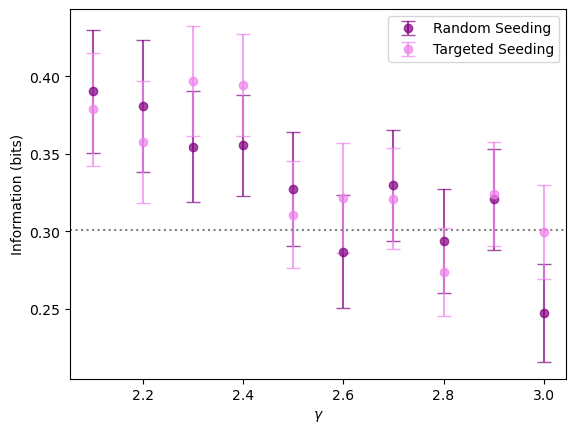

In [460]:
#color_pairs = [('blue', 'lightblue'), ('orange', 'darkorange'), ('lavender', 'purple')]
color_pairs = [("purple", "violet")]

for i, seed_beta in enumerate([1.585]):
    
    gamma_sims = seed_phase_sims.get(seed_beta)
    
    g_rand_mis = []
    g_targ_mis = []

    g_rand_mi_cis = []
    g_targ_mi_cis = []

    for gamma in gammas:
        seed_sim = gamma_sims.get(round(gamma, 3))
        mean_rand_mis = []
        for sim in seed_sim.get('random'):
            final_state = sim[1][-1]
            final_state = final_state/np.sum(final_state)
            mean_rand_mis.append(mutual_info(np.array([final_state, final_state[::-1]]), np.array([.5, .5])))

        rand_mi_arr = np.array(mean_rand_mis)
        rand_mean = np.mean(rand_mi_arr) 
        g_rand_mis.append(rand_mean)
        rand_errs = stats.t.interval(0.95, len(rand_mi_arr)-1, 
                                     loc=rand_mean,
                                     scale=stats.sem(rand_mi_arr))
        g_rand_mi_cis.append((rand_mean - rand_errs[0], rand_errs[1] - rand_mean))

        mean_targ_mis = []
        for sim in seed_sim.get('targeted'):
            final_state = sim[1][-1]
            final_state = final_state/np.sum(final_state)
            mean_targ_mis.append(mutual_info(np.array([final_state, final_state[::-1]]), np.array([.5, .5])))

        targ_mi_arr = np.array(mean_targ_mis)
        targ_mean = np.mean(targ_mi_arr)
        g_targ_mis.append(targ_mean)
        targ_errs = stats.t.interval(0.95, len(targ_mi_arr)-1, 
                                     loc=targ_mean,
                                     scale=stats.sem(targ_mi_arr))
        g_targ_mi_cis.append((targ_mean - targ_errs[0], targ_errs[1] - targ_mean))

        #mean_rand_state = np.mean(np.array([x[1][-1] for x in seed_sim.get('random')]), axis=0)
        #mean_rand_state = mean_rand_state/np.sum(mean_rand_state)
        #
        #mean_targ_state = np.mean(np.array([x[1][-1] for x in seed_sim.get('targeted')]), axis=0)
        #mean_targ_state = mean_targ_state/np.sum(mean_targ_state)

        #mi_rand = mutual_info(np.array([mean_rand_state, mean_rand_state[::-1]]), np.array([.5, .5]))
        #mi_targ = mutual_info(np.array([mean_targ_state, mean_targ_state[::-1]]), np.array([.5, .5]))
        #
        #rand_mis.append(mi_rand)
        #targ_mis.append(mi_targ)

    plt.errorbar(gammas, g_rand_mis, yerr=np.array(g_rand_mi_cis).T,
             marker='o', linestyle='None', color=color_pairs[i][0],
                capsize=5, alpha=0.7, label='Random Seeding')

    plt.errorbar(gammas, g_targ_mis, yerr=np.array(g_targ_mi_cis).T,
             marker='o', linestyle='None', color=color_pairs[i][1],
                capsize=5, alpha=0.7, label='Targeted Seeding')


plt.axhline(np.mean(homo_mis), linestyle='dotted', color='grey')
plt.xlabel(r'$\gamma$')
plt.ylabel('Information (bits)')
plt.legend()
plt.savefig('/home/sagar/modeling-info-spread/reports/figures/info_by_gamma.svg')

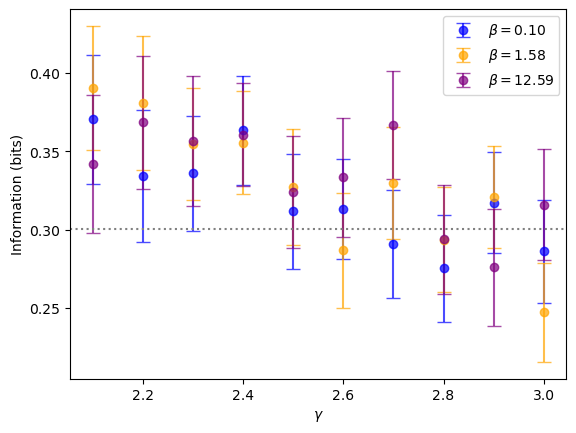

In [459]:
color_pairs = [('blue', 'lightblue'), ('orange', 'darkorange'), ('purple', 'lavender')]
#color_pairs = [("purple", "violet")]

for i, seed_beta in enumerate(seed_beta_list):
    
    gamma_sims = seed_phase_sims.get(seed_beta)
    
    g_rand_mis = []
    g_targ_mis = []

    g_rand_mi_cis = []
    g_targ_mi_cis = []

    for gamma in gammas:
        seed_sim = gamma_sims.get(round(gamma, 3))
        mean_rand_mis = []
        for sim in seed_sim.get('random'):
            final_state = sim[1][-1]
            final_state = final_state/np.sum(final_state)
            mean_rand_mis.append(mutual_info(np.array([final_state, final_state[::-1]]), np.array([.5, .5])))

        rand_mi_arr = np.array(mean_rand_mis)
        rand_mean = np.mean(rand_mi_arr) 
        g_rand_mis.append(rand_mean)
        rand_errs = stats.t.interval(0.95, len(rand_mi_arr)-1, 
                                     loc=rand_mean,
                                     scale=stats.sem(rand_mi_arr))
        g_rand_mi_cis.append((rand_mean - rand_errs[0], rand_errs[1] - rand_mean))

        mean_targ_mis = []
        for sim in seed_sim.get('targeted'):
            final_state = sim[1][-1]
            final_state = final_state/np.sum(final_state)
            mean_targ_mis.append(mutual_info(np.array([final_state, final_state[::-1]]), np.array([.5, .5])))

        targ_mi_arr = np.array(mean_targ_mis)
        targ_mean = np.mean(targ_mi_arr)
        g_targ_mis.append(targ_mean)
        targ_errs = stats.t.interval(0.95, len(targ_mi_arr)-1, 
                                     loc=targ_mean,
                                     scale=stats.sem(targ_mi_arr))
        g_targ_mi_cis.append((targ_mean - targ_errs[0], targ_errs[1] - targ_mean))

        #mean_rand_state = np.mean(np.array([x[1][-1] for x in seed_sim.get('random')]), axis=0)
        #mean_rand_state = mean_rand_state/np.sum(mean_rand_state)
        #
        #mean_targ_state = np.mean(np.array([x[1][-1] for x in seed_sim.get('targeted')]), axis=0)
        #mean_targ_state = mean_targ_state/np.sum(mean_targ_state)

        #mi_rand = mutual_info(np.array([mean_rand_state, mean_rand_state[::-1]]), np.array([.5, .5]))
        #mi_targ = mutual_info(np.array([mean_targ_state, mean_targ_state[::-1]]), np.array([.5, .5]))
        #
        #rand_mis.append(mi_rand)
        #targ_mis.append(mi_targ)

    plt.errorbar(gammas, g_rand_mis, yerr=np.array(g_rand_mi_cis).T,
             marker='o', linestyle='None', color=color_pairs[i][0],
                capsize=5, alpha=0.7, label=r'$\beta = %.2f$' % (seed_beta))

    #plt.errorbar(gammas, g_targ_mis, yerr=np.array(g_targ_mi_cis).T,
    #         marker='o', linestyle='None', color=color_pairs[i][1],
    #            capsize=5, alpha=0.7, label='Targeted')
#

plt.axhline(np.mean(homo_mis), linestyle='dotted', color='grey')
plt.xlabel(r'$\gamma$')
plt.ylabel('Information (bits)')
plt.legend()
plt.savefig('/home/sagar/modeling-info-spread/reports/figures/info_by_beta.svg')

In [435]:
test_ci_arr = np.array([t[1][-1] for t in list(seed_sims.values())[0]['random']])
test_ci_arr

array([[0.97784491, 0.02215509],
       [0.96777442, 0.03222558],
       [0.97280967, 0.02719033],
       [0.98590131, 0.01409869],
       [0.98690836, 0.01309164],
       [0.82477341, 0.17522659],
       [0.95166163, 0.04833837],
       [0.99194361, 0.00805639],
       [0.96475327, 0.03524673],
       [0.99093656, 0.00906344]])

In [228]:
## Change to dots, add confidence interval, add homogeneous line

In [230]:
stats.t.interval(0.95, len(test_ci_arr)-1, loc=np.mean(test_ci_arr, axis=0), scale=stats.sem(test_ci_arr, axis=0))

(array([0.59635126, 0.09675448]), array([0.90324552, 0.40364874]))